# Ensemble Convergence Analysis

This notebook analyzes how different realizations of the same task converge during training.

**Analyses:**
1. Distribution of minimum loss per task
2. Inner product of best stiffnesses (solution similarity)
3. Distribution of loss ratio (min/initial)
4. Attained vs target Poisson ratios scatter plot

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import copy

# Add paths
sys.path.insert(0, '../../src')


from task_generator import generate_task_config, get_all_task_configs
from config import N_TASKS, COMPRESSION_POOL, POISSON_POOL, N_NODES, BOUNDARY_MARGIN, FORCE_TYPE, get_n_nodes
from network_utils import create_auxetic_network, get_square_boundary_nodes
from elastic_network import ElasticNetwork
from training_functions_with_toggle import compute_poisson_ratio_single

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Configuration
DATA_DIR = Path('../../data/results')
print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Data directory: data/results
Exists: True


## Data Loading Utilities

In [3]:
def discover_tasks(data_dir):
    """Find all task directories in data_dir."""
    data_dir = Path(data_dir)
    tasks = []
    for d in sorted(data_dir.iterdir()):
        if d.is_dir() and d.name.startswith('task_'):
            task_seed = int(d.name.split('_')[1])
            tasks.append(task_seed)
    return tasks


def discover_realizations(task_seed, data_dir):
    """Find all completed realizations for a given task."""
    data_dir = Path(data_dir)
    task_dir = data_dir / f'task_{task_seed:02d}'
    realizations = []
    
    if not task_dir.exists():
        return realizations
    
    for d in sorted(task_dir.iterdir()):
        if d.is_dir() and d.name.startswith('realization_'):
            # Check if loss trajectory exists
            if (d / 'loss_trajectory.npy').exists():
                real_seed = int(d.name.split('_')[1])
                realizations.append(real_seed)
    
    return realizations


def load_trajectories(task_seed, realization_seed, data_dir):
    """Load loss and stiffness trajectories from .npy files."""
    data_dir = Path(data_dir)
    path = data_dir / f'task_{task_seed:02d}' / f'realization_{realization_seed:02d}'
    
    loss = np.load(path / 'loss_trajectory.npy')
    stiffness = np.load(path / 'stiffness_trajectory.npy')
    
    return loss, stiffness


def reconstruct_network_for_task(task_seed, n_nodes=N_NODES, boundary_margin=None):
    """
    Reconstruct the network for a given task using packing_seed = task_seed.
    
    Returns:
        network: ElasticNetwork object
        boundary_dict: dict with 'top', 'bottom', 'left', 'right' node indices
    """
    if boundary_margin is None:
        boundary_margin = 0.04 if get_n_nodes(task_seed) == 100 else BOUNDARY_MARGIN
    network, boundary_dict = create_auxetic_network(
        n_nodes=n_nodes,
        packing_seed=task_seed,
        boundary_margin=boundary_margin
    )
    return network, boundary_dict

In [4]:
# Discover available data
tasks = discover_tasks(DATA_DIR)
print(f"Found {len(tasks)} tasks: {tasks}")

for task in tasks:
    realizations = discover_realizations(task, DATA_DIR)
    config = generate_task_config(task)
    print(f"  Task {task}: {len(realizations)} realizations")
    print(f"    Compression strains: {config['compression_strains']}")
    print(f"    Target Poisson ratios: {config['target_poisson_ratios']}")

Found 10 tasks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Task 0: 16 realizations
    Compression strains: [-0.3, -0.15000000000000002]
    Target Poisson ratios: [-0.25, -0.5]
  Task 1: 7 realizations
    Compression strains: [-0.15000000000000002, -0.1]
    Target Poisson ratios: [-0.8, -0.3]
  Task 2: 19 realizations
    Compression strains: [-0.25, -0.1]
    Target Poisson ratios: [-1.0, -0.8]
  Task 3: 19 realizations
    Compression strains: [-0.2, -0.3]
    Target Poisson ratios: [-1.0, -0.8]
  Task 4: 19 realizations
    Compression strains: [-0.25, -0.3]
    Target Poisson ratios: [-0.8, -0.5]
  Task 5: 20 realizations
    Compression strains: [-0.3, -0.15000000000000002]
    Target Poisson ratios: [-1.0, -0.25]
  Task 6: 20 realizations
    Compression strains: [-0.25, -0.3]
    Target Poisson ratios: [-0.5, -0.25]
  Task 7: 20 realizations
    Compression strains: [-0.2, -0.3]
    Target Poisson ratios: [-0.8, -1.0]
  Task 8: 20 realizations
    Compression strains: [-0.05, -0.150000

## Load All Ensemble Data

In [34]:
# Load all data
ensemble_data = {}

for task in tqdm(tasks, desc='Loading tasks'):
    realizations = discover_realizations(task, DATA_DIR)
    task_config = generate_task_config(task)

    print(f"\nLoading Task {task} with {len(realizations)} realizations")
    print(f"  Compression strains: {task_config['compression_strains']}")
    print(f"  Poisson ratios: {task_config['target_poisson_ratios']}")
    print(f"  Packing seeds: {task_config['packing_seed']}")
    
    task_data = {
        'config': task_config,
        'realizations': {}
    }
    
    for real in realizations:
        try:
            loss, stiffness = load_trajectories(task, real, DATA_DIR)
            task_data['realizations'][real] = {
                'loss': loss,
                'stiffness': stiffness,
                'min_loss': np.min(loss),
                'initial_loss': loss[0],
                'final_loss': loss[-1],
                'best_step': np.argmin(loss),
                'best_stiffness': stiffness[np.argmin(loss)]
            }
        except Exception as e:
            print(f"  Error loading task {task}, realization {real}: {e}")
    
    ensemble_data[task] = task_data

print(f"\nLoaded data for {len(ensemble_data)} tasks")

Loading tasks:   0%|          | 0/10 [00:00<?, ?it/s]


Loading Task 0 with 16 realizations
  Compression strains: [-0.3, -0.15000000000000002]
  Poisson ratios: [-0.25, -0.5]
  Packing seeds: 0


Loading tasks:  10%|█         | 1/10 [00:00<00:05,  1.57it/s]


Loading Task 1 with 18 realizations
  Compression strains: [-0.15000000000000002, -0.1]
  Poisson ratios: [-0.8, -0.3]
  Packing seeds: 1


Loading tasks:  60%|██████    | 6/10 [00:01<00:00,  8.04it/s]

...


Loading Task 8 with 20 realizations
  Compression strains: [-0.05, -0.15000000000000002]
  Poisson ratios: [-1.0, -0.25]
  Packing seeds: 8


Loading tasks:  90%|█████████ | 9/10 [00:02<00:00,  3.67it/s]


Loading Task 9 with 20 realizations
  Compression strains: [-0.3, -0.1]
  Poisson ratios: [-1.0, -0.3]
  Packing seeds: 9


Loading tasks: 100%|██████████| 10/10 [00:02<00:00,  3.50it/s]


Loaded data for 10 tasks


## Analysis 1: Distribution of Minimum Loss Per Task

In [35]:
# Collect minimum losses per task
min_losses_data = []

for task, task_data in ensemble_data.items():
    for real, real_data in task_data['realizations'].items():
        min_losses_data.append({
            'task': task,
            'realization': real,
            'min_loss': real_data['min_loss']
        })

df_min_loss = pd.DataFrame(min_losses_data)
print(f"Total realizations: {len(df_min_loss)}")
print(df_min_loss.groupby('task')['min_loss'].describe())

Total realizations: 191
      count      mean       std           min           25%           50%  \
task                                                                        
0      15.0  0.022996  0.087958  1.430660e-07  2.797871e-06  3.154722e-05   
1      18.0  0.177393  0.238754  9.854173e-08  3.428884e-06  1.918536e-05   
2      19.0  0.795826  0.104631  6.602182e-01  7.213403e-01  7.726921e-01   
3      19.0  0.565810  0.155975  4.952952e-05  5.293175e-01  5.827765e-01   
4      19.0  0.814613  0.194032  4.528928e-01  7.404890e-01  8.280653e-01   
5      20.0  0.546070  0.360915  2.694474e-02  7.729947e-02  6.592203e-01   
6      19.0  0.009984  0.043381  8.811087e-08  3.472520e-06  2.499233e-05   
7      20.0  0.056976  0.254765  9.133414e-09  2.547209e-07  1.588837e-06   
8      17.0  0.000009  0.000021  4.815380e-11  5.186706e-07  2.004326e-06   
9      19.0  0.000013  0.000052  6.374258e-10  1.630769e-07  6.769880e-07   

           75%       max  
task                    

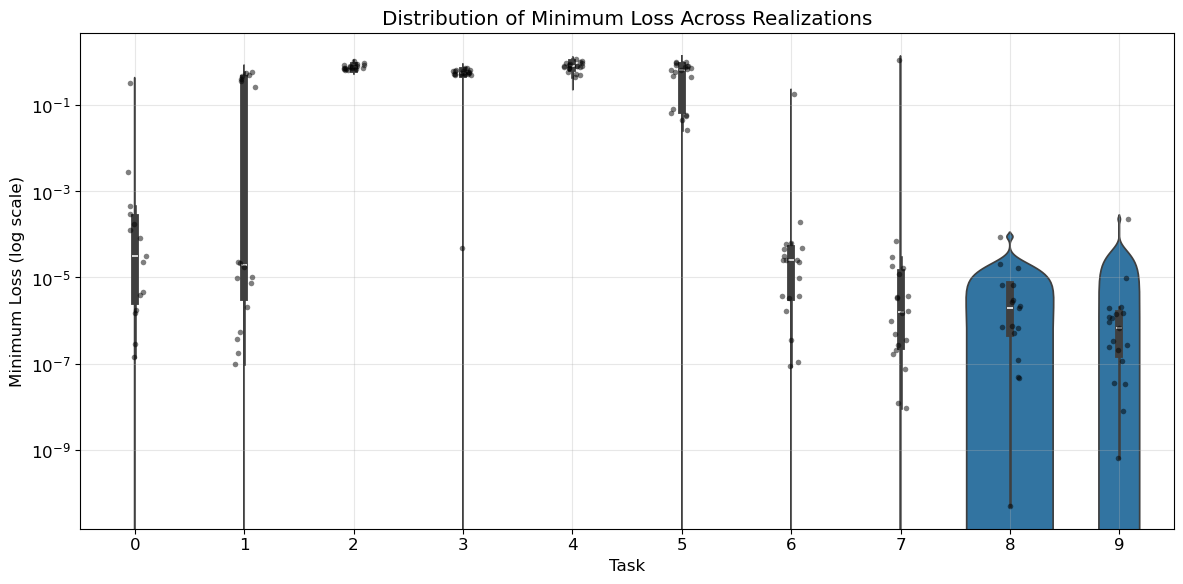

In [36]:
# Violin plot of minimum loss distribution per task
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_min_loss, x='task', y='min_loss', ax=ax, inner='box')
sns.stripplot(data=df_min_loss, x='task', y='min_loss', ax=ax, 
              color='black', alpha=0.5, size=4)

ax.set_yscale('log')
ax.set_xlabel('Task')
ax.set_ylabel('Minimum Loss (log scale)')
ax.set_title('Distribution of Minimum Loss Across Realizations')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 2: Inner Product of Best Stiffnesses

In [37]:
def compute_stiffness_similarity_matrix(task_data):
    """
    Compute pairwise cosine similarity of best stiffnesses for a task.
    
    Returns:
        similarity_matrix: (n_realizations, n_realizations) matrix
        realization_ids: list of realization indices
    """
    realizations = task_data['realizations']
    realization_ids = sorted(realizations.keys())
    n_real = len(realization_ids)
    
    # Collect best stiffnesses
    for r in realization_ids:
        print(r, len(realizations[r]['best_stiffness']), type(realizations[r]['best_stiffness']))
    stiffnesses = np.array([realizations[r]['best_stiffness'] for r in realization_ids])
    
    # Normalize
    norms = np.linalg.norm(stiffnesses, axis=1, keepdims=True)
    normalized = stiffnesses / (norms + 1e-16)
    
    # Compute cosine similarity
    similarity_matrix = normalized @ normalized.T
    
    return similarity_matrix, realization_ids

In [38]:
# Compute similarity matrices for all tasks
similarity_data = {}

for task, task_data in ensemble_data.items():
    if len(task_data['realizations']) >= 2:
        sim_matrix, real_ids = compute_stiffness_similarity_matrix(task_data)
        similarity_data[task] = {
            'matrix': sim_matrix,
            'realization_ids': real_ids
        }

5 231 <class 'numpy.ndarray'>
6 231 <class 'numpy.ndarray'>
7 231 <class 'numpy.ndarray'>
8 231 <class 'numpy.ndarray'>
9 231 <class 'numpy.ndarray'>
10 231 <class 'numpy.ndarray'>
11 231 <class 'numpy.ndarray'>
12 231 <class 'numpy.ndarray'>
13 231 <class 'numpy.ndarray'>
14 231 <class 'numpy.ndarray'>
15 231 <class 'numpy.ndarray'>
16 231 <class 'numpy.ndarray'>
17 231 <class 'numpy.ndarray'>
18 231 <class 'numpy.ndarray'>
19 231 <class 'numpy.ndarray'>
29 231 <class 'numpy.ndarray'>
2 225 <class 'numpy.ndarray'>
3 225 <class 'numpy.ndarray'>
4 225 <class 'numpy.ndarray'>
5 225 <class 'numpy.ndarray'>
6 225 <class 'numpy.ndarray'>
7 225 <class 'numpy.ndarray'>
8 225 <class 'numpy.ndarray'>
9 225 <class 'numpy.ndarray'>
10 225 <class 'numpy.ndarray'>
11 225 <class 'numpy.ndarray'>
12 225 <class 'numpy.ndarray'>
13 225 <class 'numpy.ndarray'>
14 225 <class 'numpy.ndarray'>
15 225 <class 'numpy.ndarray'>
16 225 <class 'numpy.ndarray'>
17 225 <class 'numpy.ndarray'>
18 225 <class 'numpy.

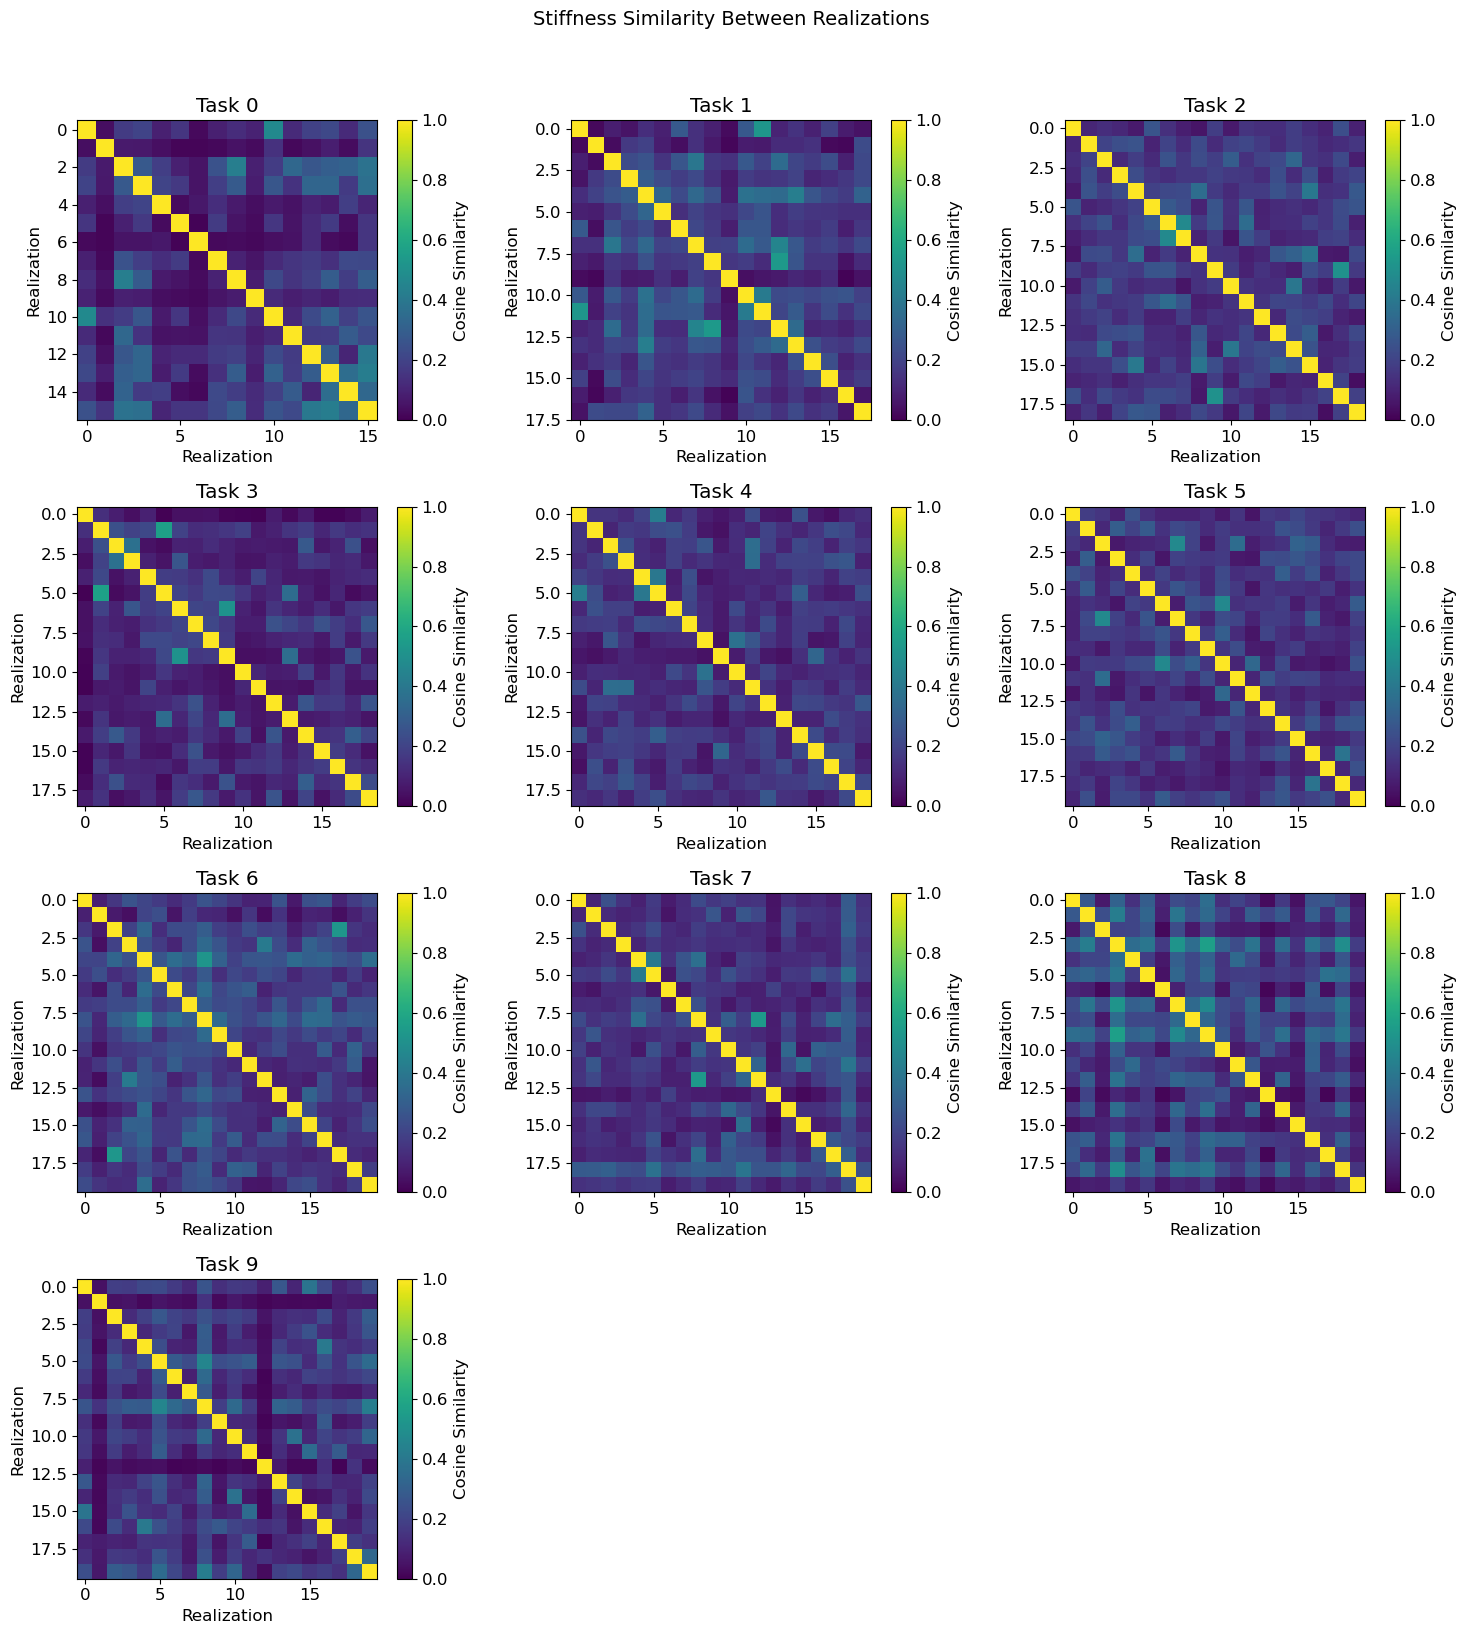

In [40]:
# Plot similarity heatmaps for each task
n_tasks_plot = len(similarity_data)
ncols = min(3, n_tasks_plot)
nrows = (n_tasks_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
if n_tasks_plot == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (task, sim_data) in enumerate(similarity_data.items()):
    ax = axes[idx]
    im = ax.imshow(sim_data['matrix'], vmin=0, vmax=1, cmap='viridis')
    ax.set_title(f'Task {task}')
    ax.set_xlabel('Realization')
    ax.set_ylabel('Realization')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')

# Hide unused axes
for idx in range(n_tasks_plot, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Stiffness Similarity Between Realizations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

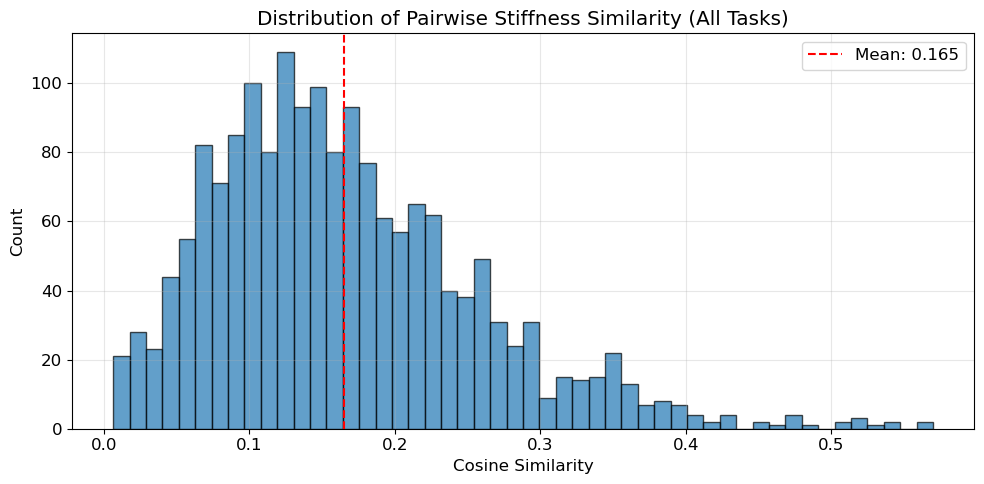


Summary of off-diagonal similarities:
count    1736.000000
mean        0.165279
std         0.091058
min         0.006353
25%         0.099683
50%         0.150386
75%         0.215831
max         0.570029
Name: similarity, dtype: float64


In [41]:
# Collect off-diagonal similarity values across all tasks
off_diagonal_similarities = []

for task, sim_data in similarity_data.items():
    matrix = sim_data['matrix']
    n = matrix.shape[0]
    # Extract upper triangle (excluding diagonal)
    for i in range(n):
        for j in range(i+1, n):
            off_diagonal_similarities.append({
                'task': task,
                'similarity': matrix[i, j]
            })

df_similarity = pd.DataFrame(off_diagonal_similarities)

# Histogram of similarities
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_similarity['similarity'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(df_similarity['similarity'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df_similarity["similarity"].mean():.3f}')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pairwise Stiffness Similarity (All Tasks)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of off-diagonal similarities:")
print(df_similarity['similarity'].describe())

## Analysis 3: Distribution of Loss Ratio (min/initial)

In [42]:
# Collect loss ratios
loss_ratio_data = []

for task, task_data in ensemble_data.items():
    for real, real_data in task_data['realizations'].items():
        ratio = real_data['min_loss'] / real_data['initial_loss']
        loss_ratio_data.append({
            'task': task,
            'realization': real,
            'loss_ratio': ratio,
            'initial_loss': real_data['initial_loss'],
            'min_loss': real_data['min_loss']
        })

df_loss_ratio = pd.DataFrame(loss_ratio_data)
print("Loss ratio (min/initial) statistics:")
print(df_loss_ratio.groupby('task')['loss_ratio'].describe())

Loss ratio (min/initial) statistics:
      count      mean       std           min           25%       50%  \
task                                                                    
0      15.0  0.067461  0.257988  4.379406e-07  6.430943e-06  0.000122   
1      18.0  0.388902  0.501621  2.768143e-07  9.708590e-06  0.000048   
2      19.0  1.000000  0.000000  1.000000e+00  1.000000e+00  1.000000   
3      19.0  0.947372  0.229400  6.863229e-05  1.000000e+00  1.000000   
4      19.0  1.000000  0.000000  1.000000e+00  1.000000e+00  1.000000   
5      20.0  0.722420  0.435264  3.912681e-02  1.104590e-01  1.000000   
6      19.0  0.052854  0.229362  9.406132e-07  2.694004e-05  0.000126   
7      20.0  0.050007  0.223605  7.048631e-09  2.407918e-07  0.000001   
8      17.0  0.000010  0.000021  4.711666e-11  4.686276e-07  0.000002   
9      19.0  0.000023  0.000092  8.116288e-10  2.217036e-07  0.000001   

           75%       max  
task                      
0     0.000639  1.000000  
1    

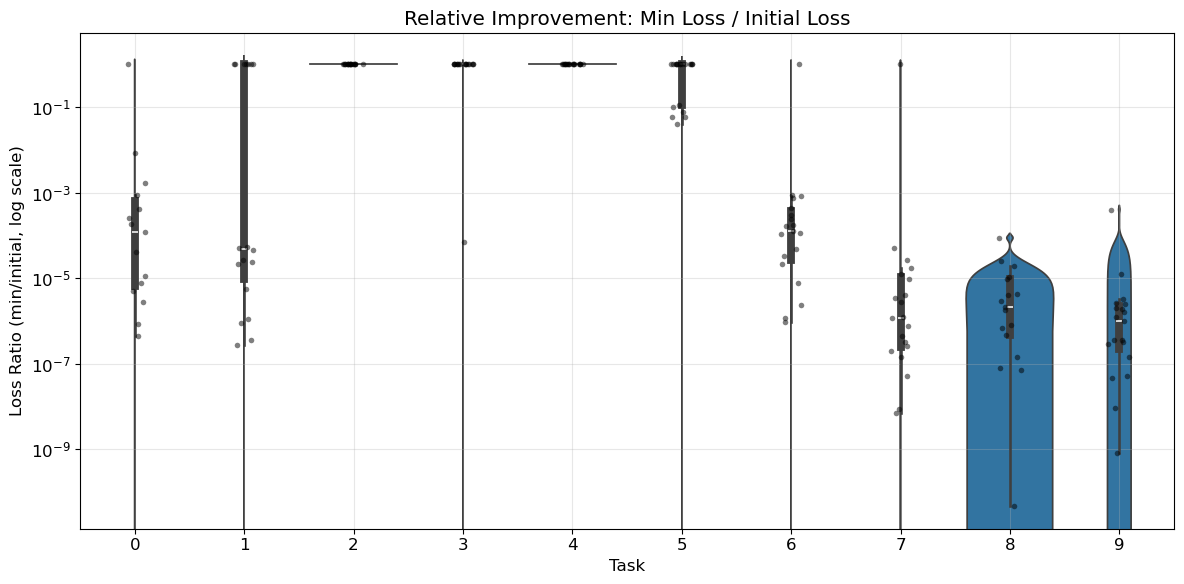

In [43]:
# Violin plot of loss ratio distribution per task
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_loss_ratio, x='task', y='loss_ratio', ax=ax, inner='box')
sns.stripplot(data=df_loss_ratio, x='task', y='loss_ratio', ax=ax, 
              color='black', alpha=0.5, size=4)

ax.set_yscale('log')
ax.set_xlabel('Task')
ax.set_ylabel('Loss Ratio (min/initial, log scale)')
ax.set_title('Relative Improvement: Min Loss / Initial Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis 4: Attained vs Target Poisson Ratios

In [44]:
def compute_attained_poisson_ratios(task_seed, best_stiffness, data_dir=DATA_DIR,
                                    n_strain_steps=20, force_type=FORCE_TYPE):
    """
    Compute attained Poisson ratios for a network with given stiffnesses.
    
    Returns:
        attained_poissons: list of 2 floats (one per subtask)
        target_poissons: list of 2 floats
        compression_strains: list of 2 floats
    """
    # Get task configuration
    task_config = generate_task_config(task_seed)
    compression_strains = task_config['compression_strains']
    target_poissons = task_config['target_poisson_ratios']
    
    # Reconstruct network
    network, boundary_dict = reconstruct_network_for_task(task_seed)
    
    # Set the trained stiffnesses
    network.stiffnesses = np.array(best_stiffness)
    
    # Get boundary nodes
    top_nodes = boundary_dict['top']
    bottom_nodes = boundary_dict['bottom']
    left_nodes = boundary_dict['left']
    right_nodes = boundary_dict['right']
    
    # Compute attained Poisson ratio for each compression strain
    attained_poissons = []
    for cs in compression_strains:
        pr = compute_poisson_ratio_single(
            copy.deepcopy(network), 
            top_nodes, bottom_nodes, left_nodes, right_nodes,
            cs, n_strain_steps=n_strain_steps, force_type=force_type
        )
        attained_poissons.append(pr)
    
    return attained_poissons, target_poissons, compression_strains

In [45]:
# Compute attained Poisson ratios for all realizations
# NOTE: This is computationally expensive - you may want to limit the number of realizations

MAX_REALIZATIONS_PER_TASK = 5  # Set to None to process all

poisson_scatter_data = []

for task, task_data in tqdm(ensemble_data.items(), desc='Computing Poisson ratios'):
    realizations = list(task_data['realizations'].keys())
    if MAX_REALIZATIONS_PER_TASK is not None:
        realizations = realizations[:MAX_REALIZATIONS_PER_TASK]
    
    for real in realizations:
        real_data = task_data['realizations'][real]
        best_stiffness = real_data['best_stiffness']
        
        try:
            attained, target, cs = compute_attained_poisson_ratios(
                task, best_stiffness
            )
            
            # Add both subtasks as separate data points
            for subtask_idx in range(2):
                poisson_scatter_data.append({
                    'task': task,
                    'realization': real,
                    'subtask': subtask_idx,
                    'compression_strain': cs[subtask_idx],
                    'target_poisson': target[subtask_idx],
                    'attained_poisson': attained[subtask_idx],
                    'min_loss': real_data['min_loss']
                })
        except Exception as e:
            print(f"  Error computing Poisson for task {task}, real {real}: {e}")

df_poisson = pd.DataFrame(poisson_scatter_data)
print(f"\nComputed Poisson ratios for {len(df_poisson)} data points")

progress: 100%|##########| 1000.00/1000.00 [00:07<00:00], ?it/s]
progress: 100%|##########| 1000.00/1000.00 [00:07<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:07<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:07<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:08<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:06<00:00]6:27, 43.01s/it]
progress: 100%|##########| 1000.00/1000.00 [00:06<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:05<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:05<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:05<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:09<00:00]4:44, 35.62s/it]
progress: 100%|##########| 1000.00/1000.00 [00:09<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:08<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:07<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:07<00:00]
progress: 100%|##########| 1000.00/1000.00 [00:05<00:00]4:41, 40.27s/it]
progress: 100%|##########| 1000.


Computed Poisson ratios for 100 data points


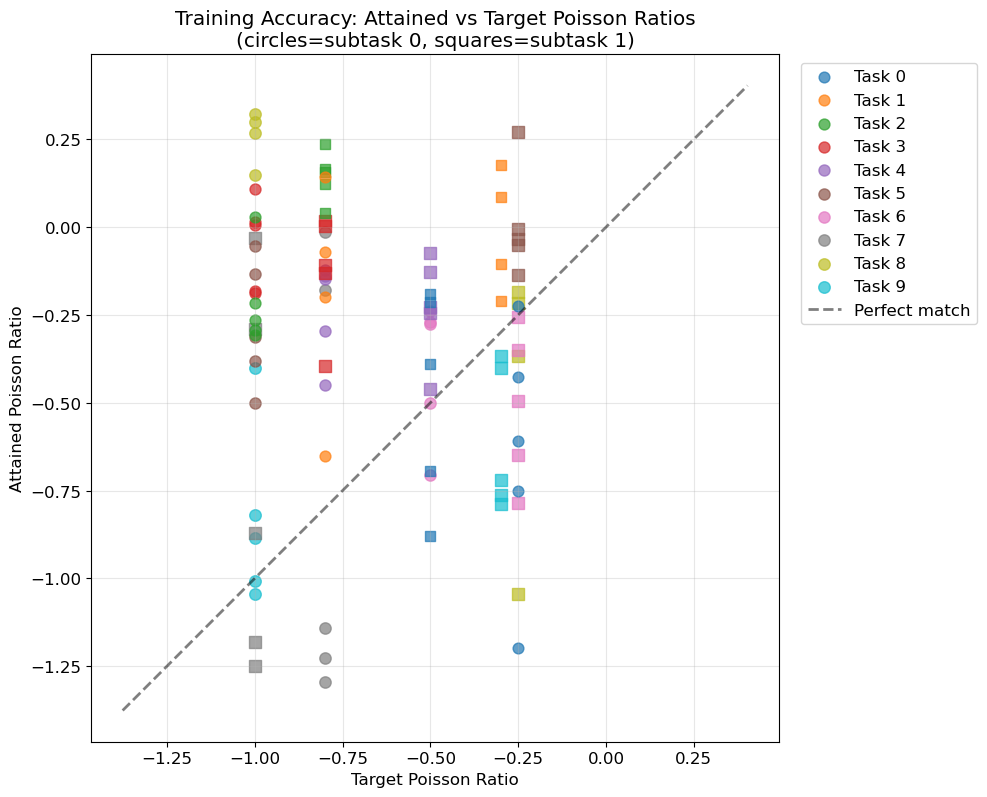

In [46]:
# Scatter plot: attained vs target Poisson ratios
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each task with different color
colors = plt.cm.tab10.colors
markers = ['o', 's']  # Circle for subtask 0, square for subtask 1

for task_idx, task in enumerate(df_poisson['task'].unique()):
    subset = df_poisson[df_poisson['task'] == task]
    color = colors[task_idx % len(colors)]
    
    for subtask in [0, 1]:
        sub_subset = subset[subset['subtask'] == subtask]
        label = f'Task {task}, Subtask {subtask}' if subtask == 0 else None
        ax.scatter(sub_subset['target_poisson'], sub_subset['attained_poisson'],
                   c=[color], marker=markers[subtask], alpha=0.7, s=task_idx+60,
                   label=f'Task {task}' if subtask == 0 else None, zorder=-task_idx)

# Diagonal line (perfect match)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Perfect match')

ax.set_xlabel('Target Poisson Ratio')
ax.set_ylabel('Attained Poisson Ratio')
ax.set_title('Training Accuracy: Attained vs Target Poisson Ratios\n(circles=subtask 0, squares=subtask 1)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [47]:
# Compute error statistics
df_poisson['error'] = df_poisson['attained_poisson'] - df_poisson['target_poisson']
df_poisson['abs_error'] = np.abs(df_poisson['error'])
df_poisson['relative_error'] = df_poisson['abs_error'] / np.abs(df_poisson['target_poisson'])

print("Error statistics:")
print(df_poisson[['error', 'abs_error', 'relative_error']].describe())

print("\nMean absolute error by task:")
print(df_poisson.groupby('task')['abs_error'].mean())

Error statistics:
           error  abs_error  relative_error
count  96.000000  96.000000       96.000000
mean    0.332778   0.504763        0.824202
std     0.514904   0.345781        0.605768
min    -0.948643   0.000551        0.001103
25%    -0.016596   0.205185        0.454862
50%     0.298922   0.469017        0.754013
75%     0.731436   0.785039        1.023781
max     1.321916   1.321916        3.794571

Mean absolute error by task:
task
0    0.329417
1    0.445955
2    0.867050
3    0.814555
4    0.420824
5    0.491721
6    0.221198
7    0.491268
8    0.755304
9    0.248689
Name: abs_error, dtype: float64


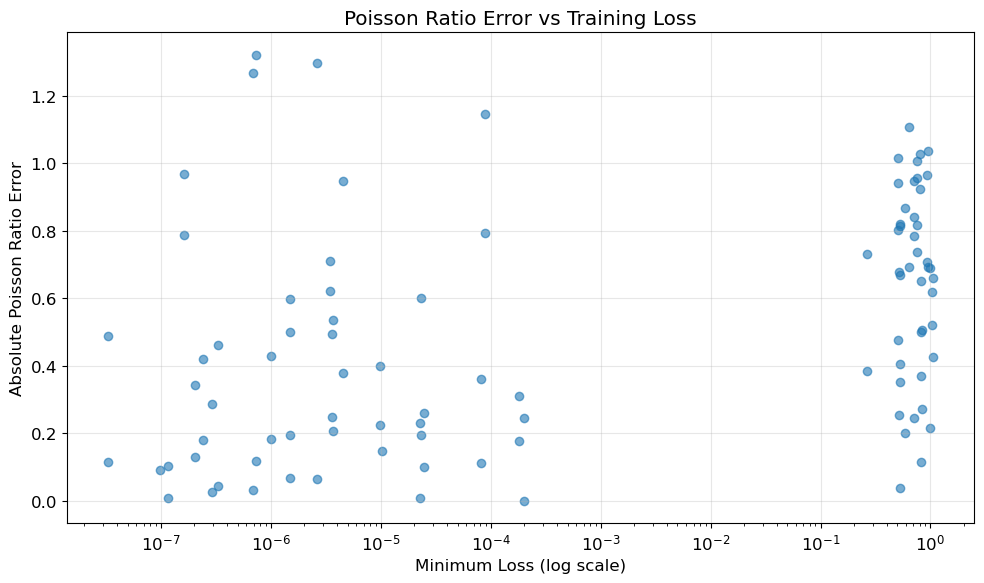

In [48]:
# Error vs min_loss scatter
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_poisson['min_loss'], df_poisson['abs_error'], alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Minimum Loss (log scale)')
ax.set_ylabel('Absolute Poisson Ratio Error')
ax.set_title('Poisson Ratio Error vs Training Loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
print("="*60)
print("ENSEMBLE CONVERGENCE SUMMARY")
print("="*60)

print(f"\nTotal tasks analyzed: {len(ensemble_data)}")
total_realizations = sum(len(td['realizations']) for td in ensemble_data.values())
print(f"Total realizations: {total_realizations}")

print(f"\nMinimum loss statistics (across all realizations):")
all_min_losses = [rd['min_loss'] for td in ensemble_data.values() for rd in td['realizations'].values()]
print(f"  Mean: {np.mean(all_min_losses):.4e}")
print(f"  Median: {np.median(all_min_losses):.4e}")
print(f"  Min: {np.min(all_min_losses):.4e}")
print(f"  Max: {np.max(all_min_losses):.4e}")

print(f"\nStiffness similarity (off-diagonal):")
print(f"  Mean: {df_similarity['similarity'].mean():.4f}")
print(f"  Std: {df_similarity['similarity'].std():.4f}")

if len(df_poisson) > 0:
    print(f"\nPoisson ratio accuracy:")
    print(f"  Mean absolute error: {df_poisson['abs_error'].mean():.4f}")
    print(f"  Mean relative error: {df_poisson['relative_error'].mean():.2%}")

print("="*60)

ENSEMBLE CONVERGENCE SUMMARY

Total tasks analyzed: 6
Total realizations: 112

Minimum loss statistics (across all realizations):
  Mean: nan
  Median: nan
  Min: nan
  Max: nan

Stiffness similarity (off-diagonal):
  Mean: 0.1913
  Std: 0.1056

Poisson ratio accuracy:
  Mean absolute error: 0.1636
  Mean relative error: 55.68%
